# Modelo de Regressão polinomial

Para a predição dos valores de NDVI, utilizamos regressão polinomial, pois o comportamento do NDVI ao longo do tempo segue uma curva característica, com picos bem definidos durante os períodos de cultivo, especialmente nas safras de soja e algodão.

As variáveis utilizadas no treinamento foram: a média móvel do NDVI, os valores de Coerência de Radar (CR) do Sentinel-1 e o dia juliano.

Durante o processo de treinamento, enfrentamos alguns desafios, descritos a seguir:

**1. Colinearidade com o NDVI:**

Não foi possível utilizar diretamente o NDVI como variável de entrada para prever ele mesmo, pois isso causaria colinearidade perfeita — uma situação em que a variável dependente está totalmente correlacionada com uma das variáveis independentes, resultando em um coeficiente de correlação igual a 1.

Para contornar esse problema, optamos por utilizar a média móvel das últimas observações disponíveis do NDVI como uma feature substituta.

**2. Desbalanceamento de classes:**

Ao longo do ano, o período em que as áreas estão cultivadas é maior do que os períodos em que estão em pousio ou sem cultura. Isso gera uma distribuição desigual dos valores de NDVI, com predominância de valores mais baixos, o que causa desbalanceamento durante o treinamento. 

Para lidar com esse problema, utilizamos a métrica Weighted Mean Squared Error (WMSE), atribuindo pesos maiores às faixas de NDVI menos representadas, buscando equilibrar a influência de diferentes classes na modelagem.

### Avalição do modelo

Para avaliar o desempenho do modelo de regressão polinomial utilizado na predição dos valores de NDVI, adotamos a métrica Weighted Mean Squared Error (WMSE). Essa métrica foi escolhida devido ao desbalanceamento das classes de NDVI, atribuindo pesos maiores às faixas menos representadas, garantindo que o modelo não favorecesse as classes mais frequentes.

Resultados Obtidos:

    Weighted MSE no conjunto de teste: 0.00607

    Weighted MSE por fold (validação cruzada):

    Fold 1: 0.00607

    Fold 2: 0.00609

    Fold 3: 0.00611

    Fold 4: 0.00605

    Fold 5: 0.00610

    Média do Weighted MSE: 0.00608

    Desvio padrão do Weighted MSE: 0.000024

### Interpretação dos Resultados:

**Baixo Erro Médio:**
O valor médio do WMSE (0.00608) indica que o modelo conseguiu capturar bem a relação entre as variáveis preditoras e o NDVI, com erros relativamente baixos.

**Consistência nos Folds:**
O desvio padrão do WMSE entre os folds foi muito pequeno (0.000024), o que demonstra que o modelo é consistente e apresenta desempenho estável em diferentes divisões dos dados.


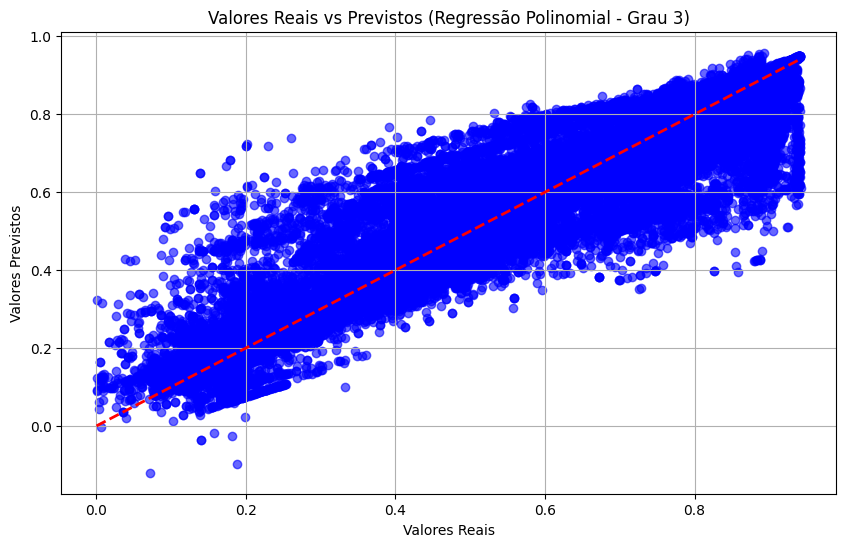

O gráfico mostra que o modelo conseguiu seguir a tendência dos dados, com a maioria dos pontos próximos à linha de identidade (linha vermelha). Isso indica que o modelo é capaz de prever valores de NDVI com boa precisão.

**Conclusão:**

O modelo de regressão polinomial apresentou um desempenho satisfatório, com erros baixos e consistentes. A utilização do WMSE foi essencial para lidar com o desbalanceamento das classes de NDVI, garantindo que o modelo não favorecesse as faixas mais frequentes. Apesar disso, é importante continuar monitorando o desempenho em faixas menos representadas e, se necessário, ajustar o modelo ou as métricas de avaliação para melhorar ainda mais a precisão.

# Geração das imagens NDVI Predicted

Com os valores preditos para cada pontos amostral, geramos imagens .tif através da interpolação IDW com um pixel de 20m, para o ano de 2025 e fizemos algumas comparações com as imagens reais de NDVI do Sentinel-2.





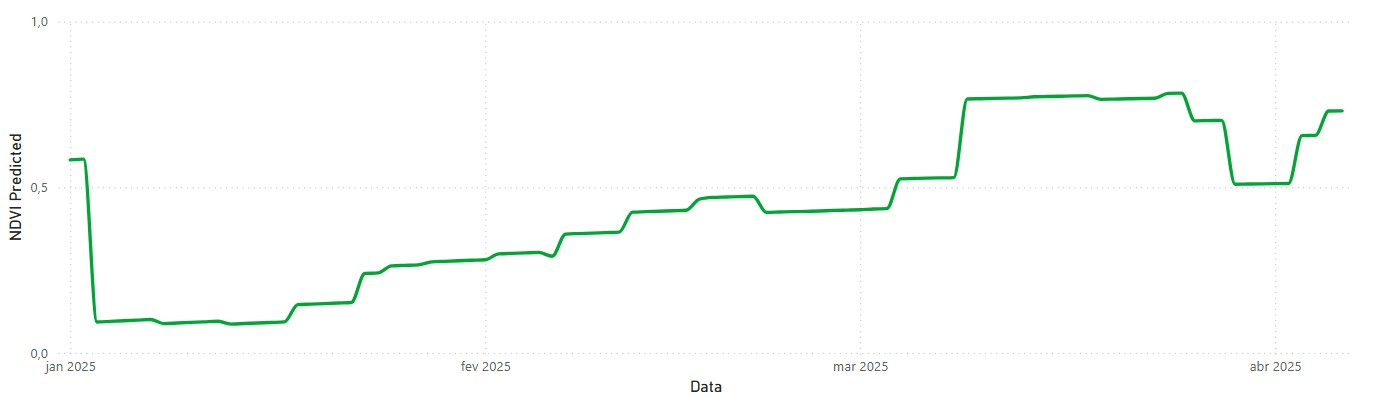 

Como visto nas imagens acima, os valores de NDVI caem em janeiro e voltar a subir no começo de fevereiro, devido ao final da safra e começo da safrinha.

Como geramos imagens de Janeiro a Abril, fizemos algumas comparações com as imagens preditas com as imagens originais de NDVI.


### Janeiro

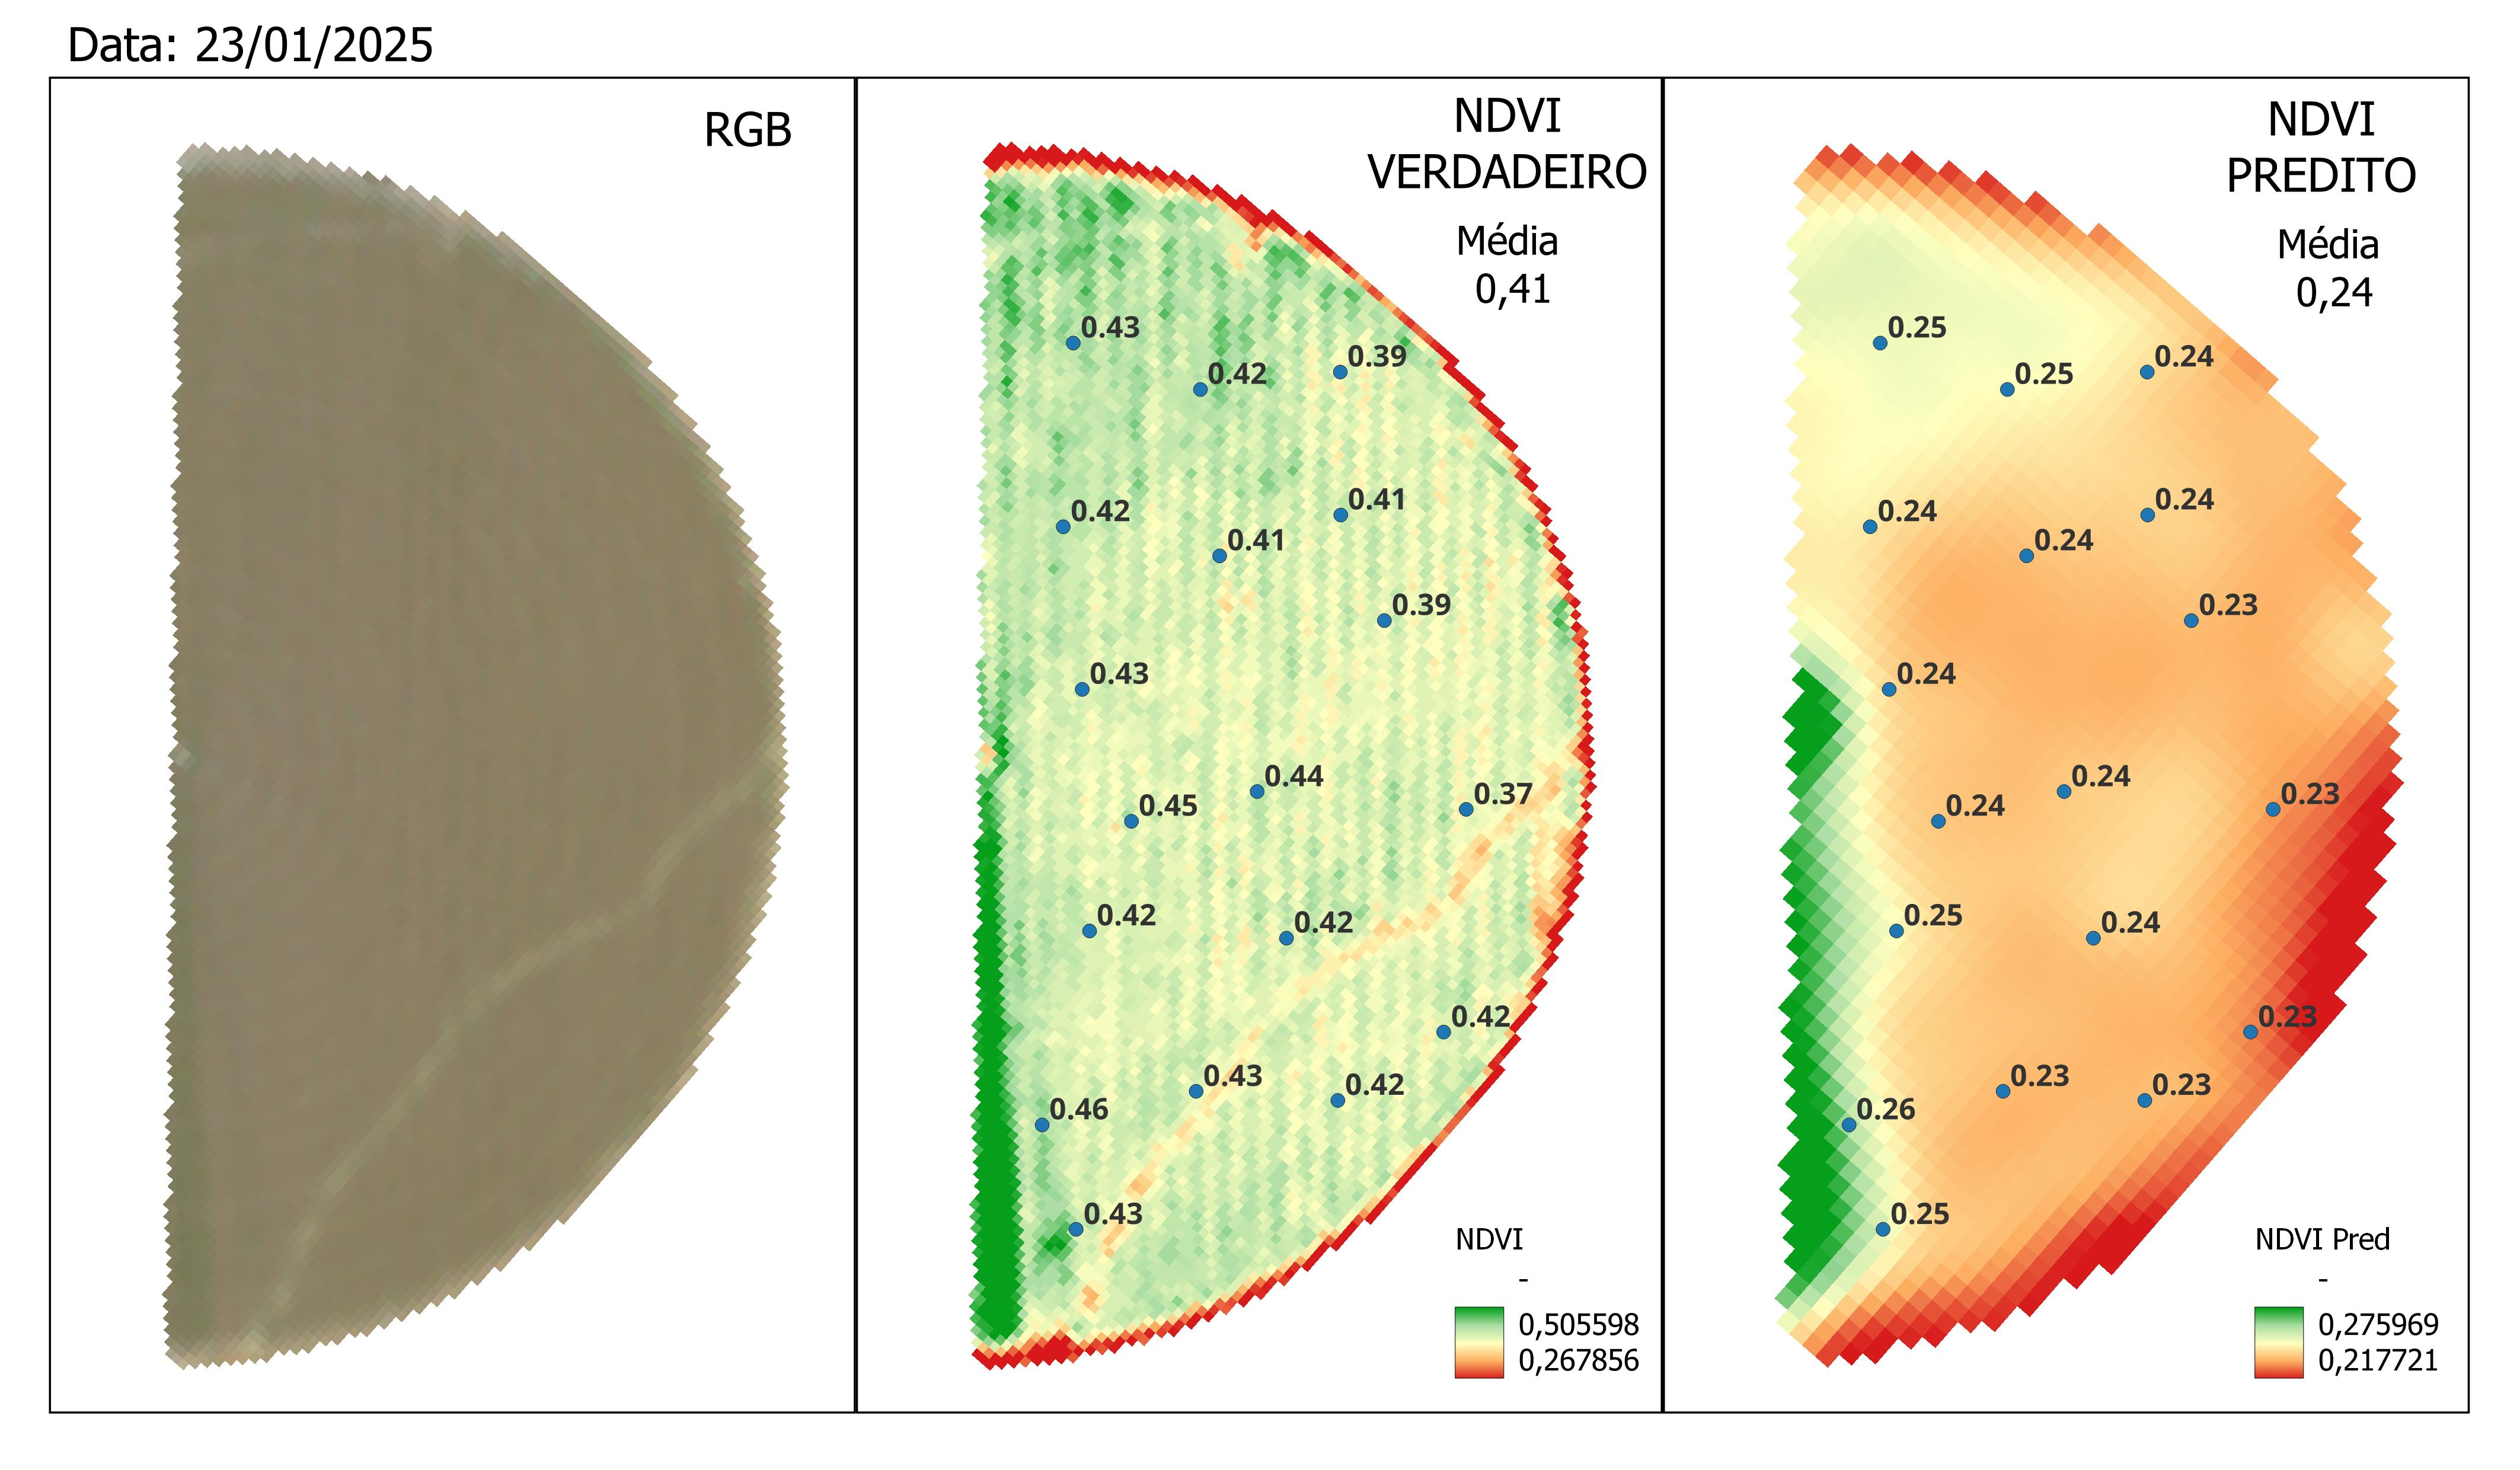

### Fevereiro

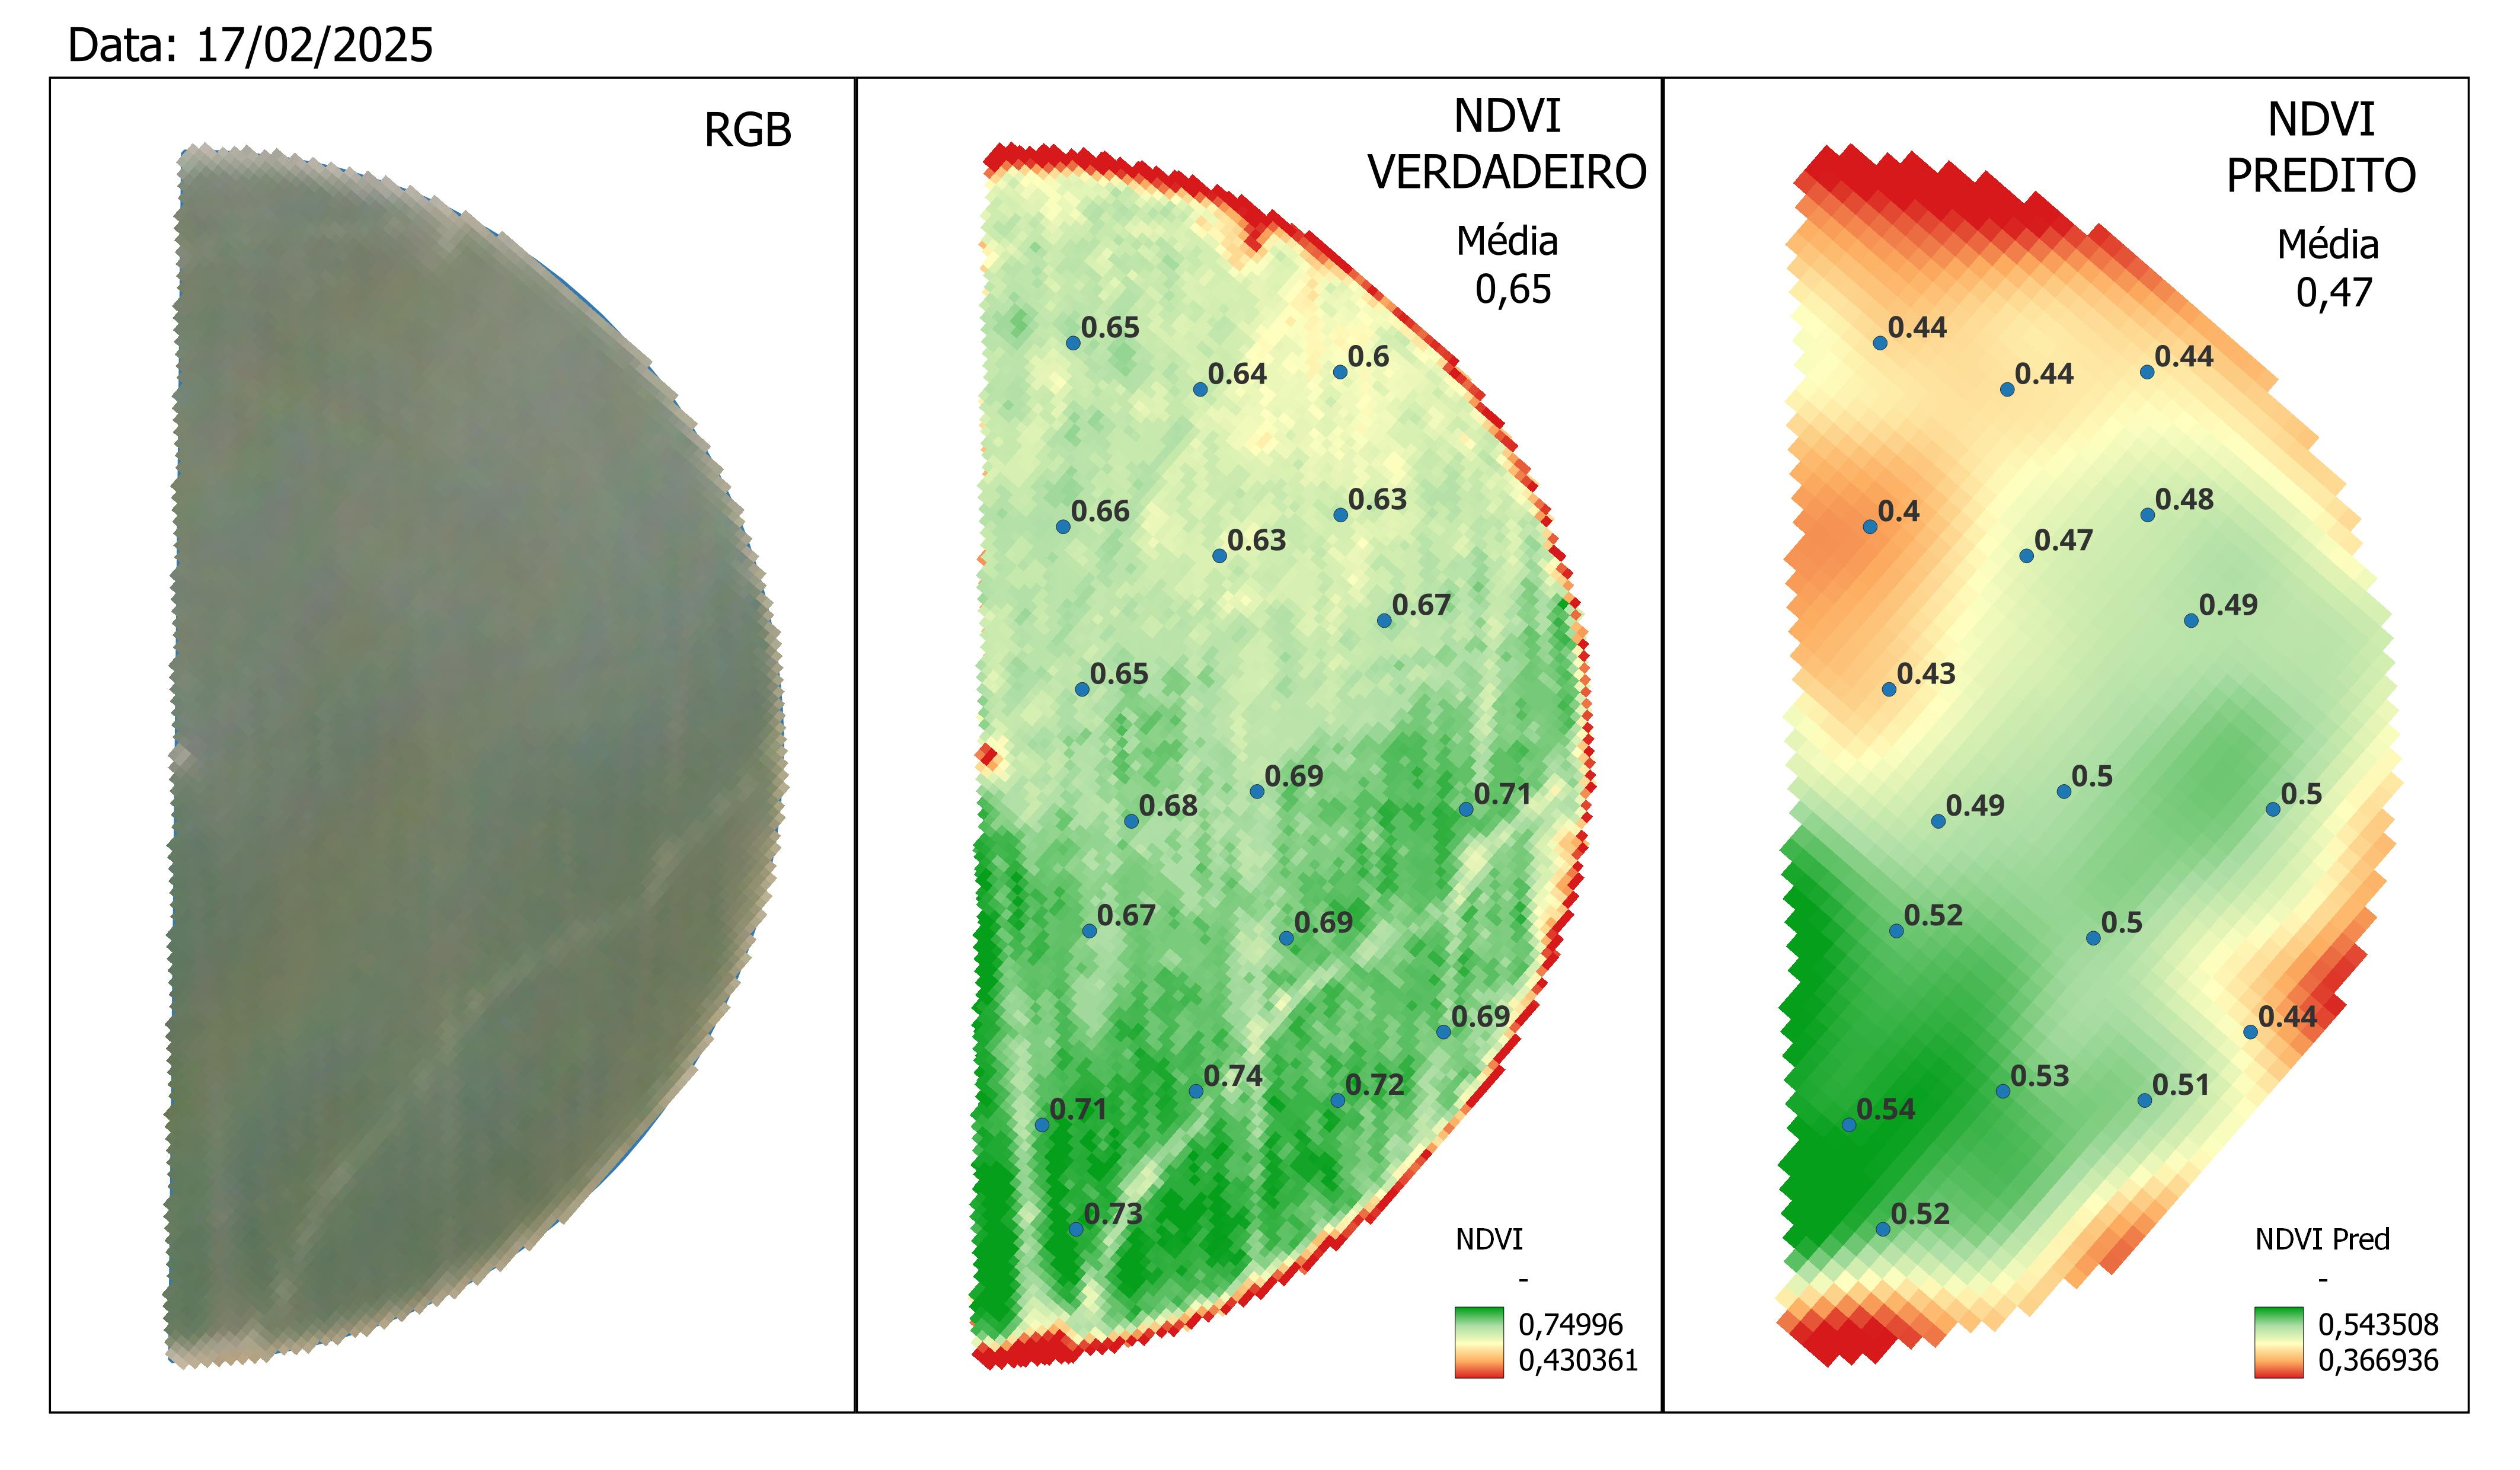

### Março

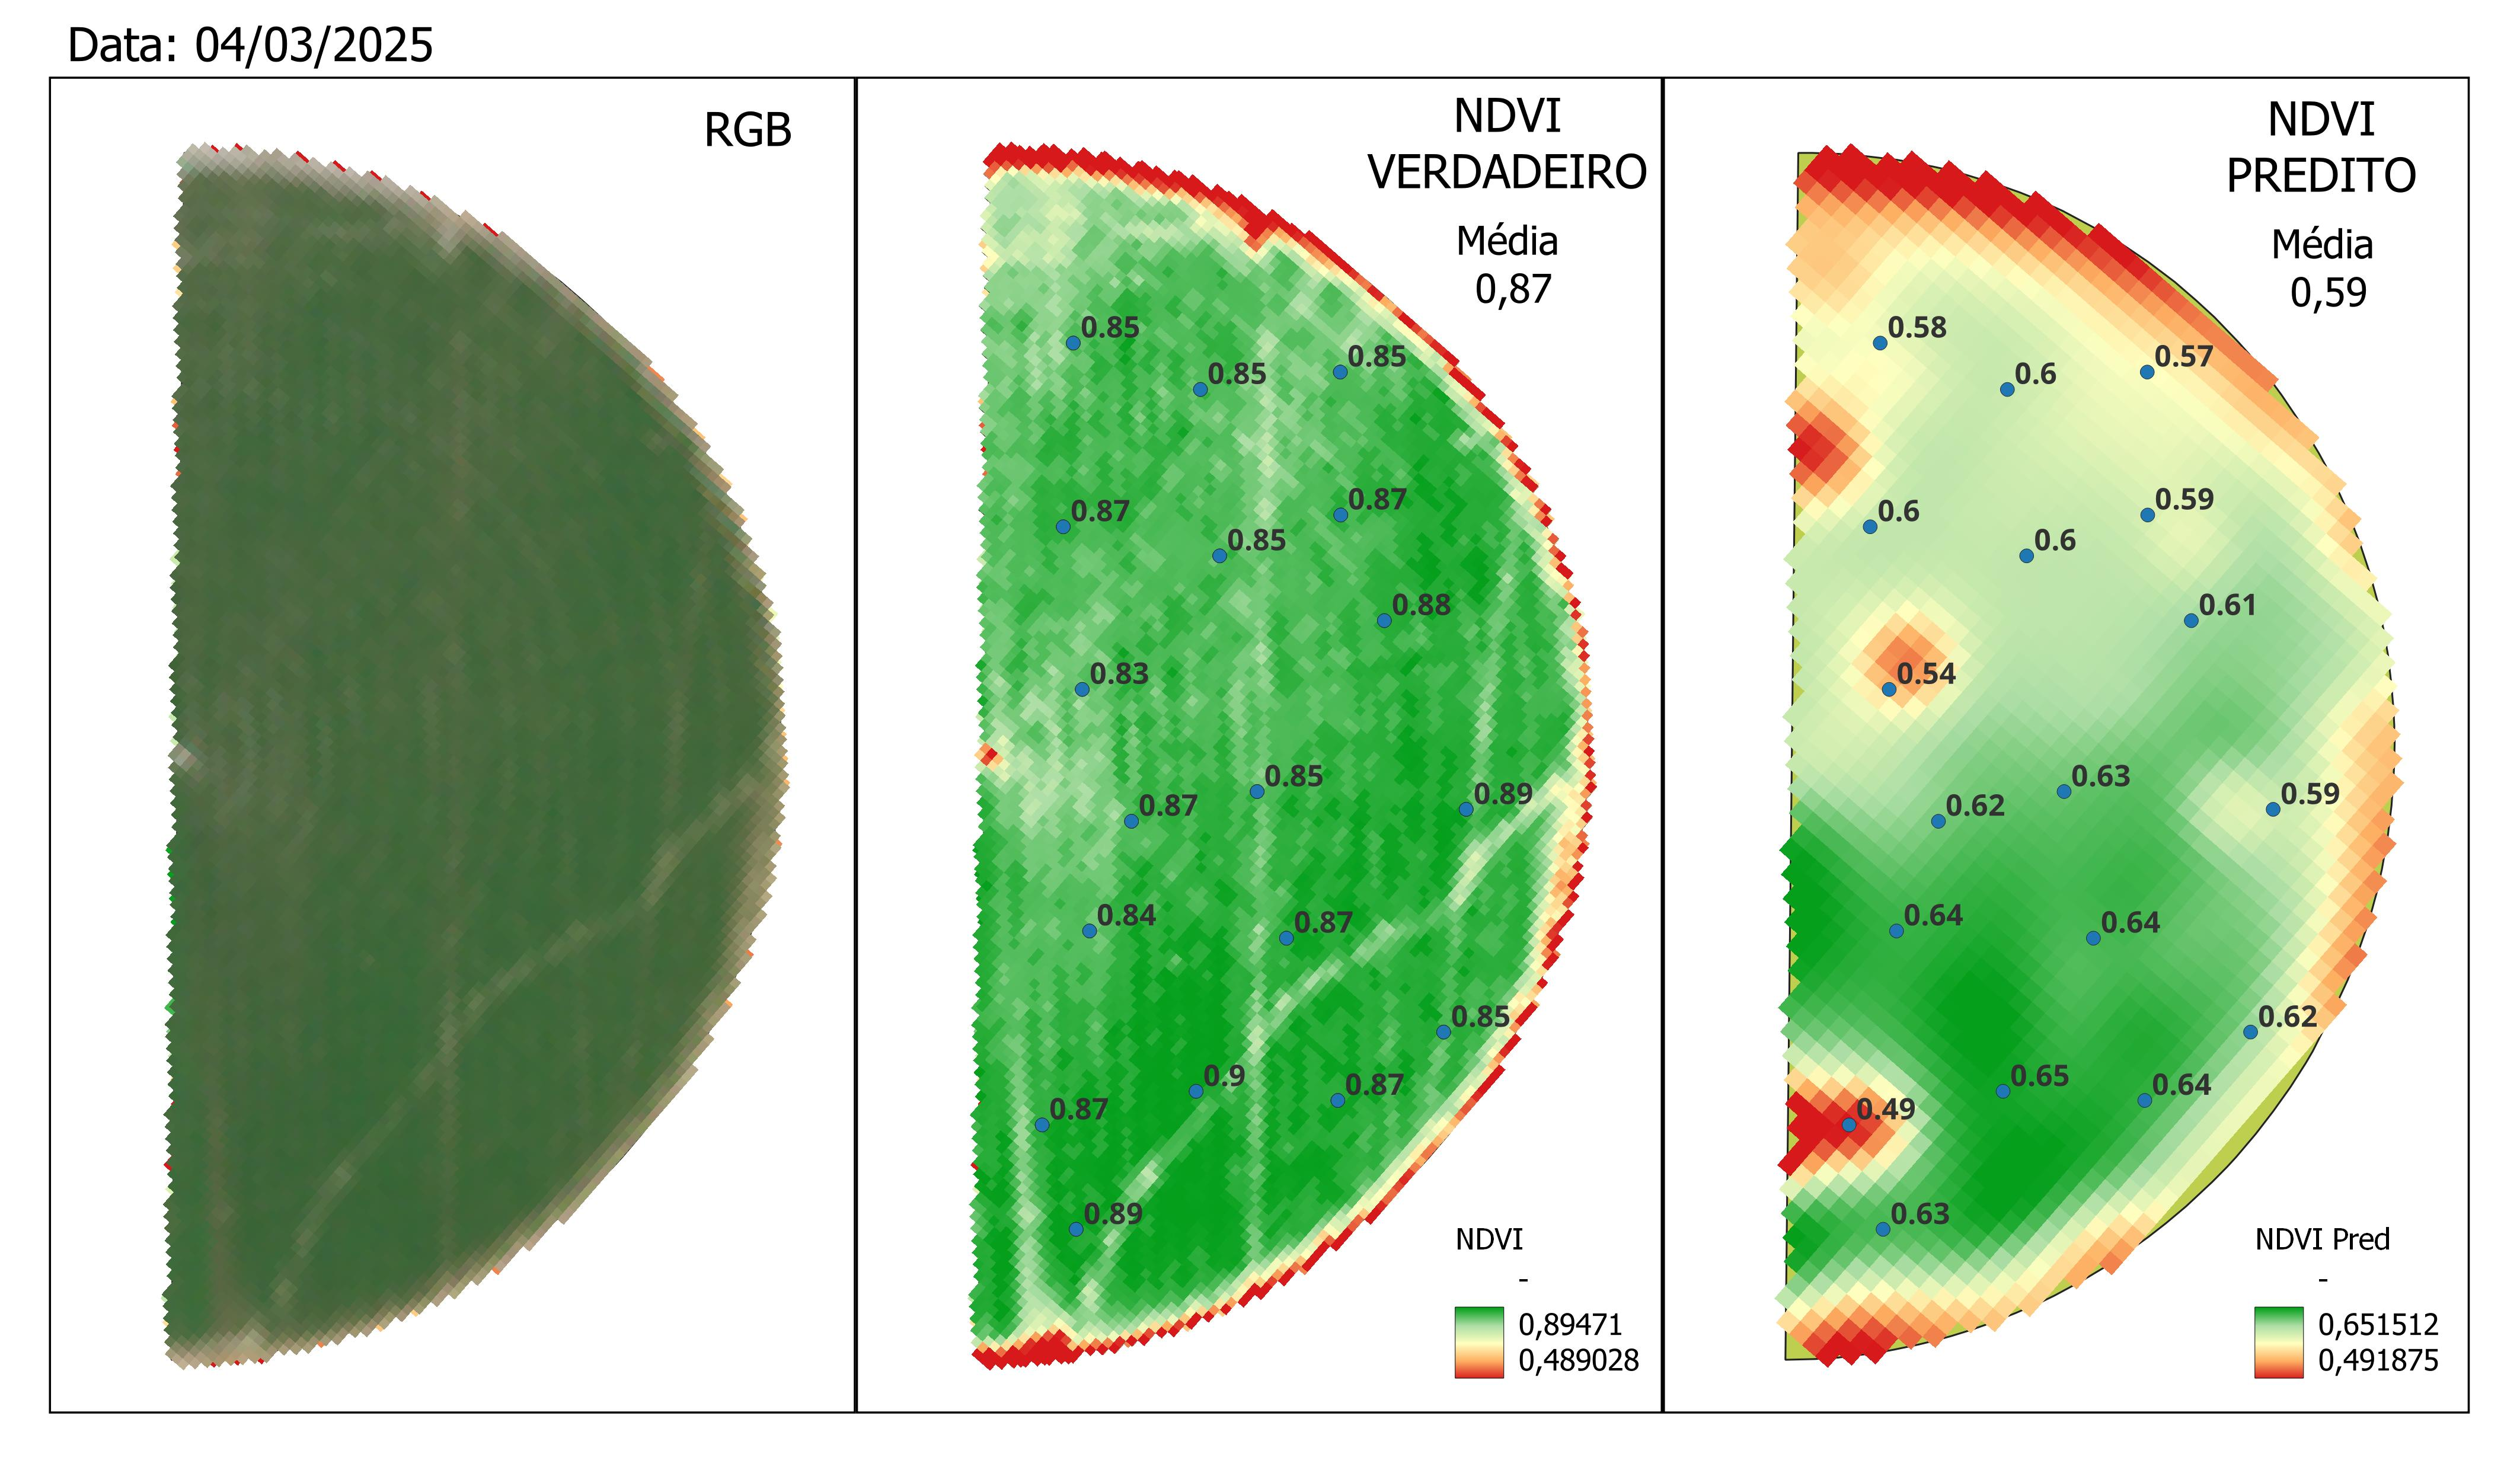

### Abril

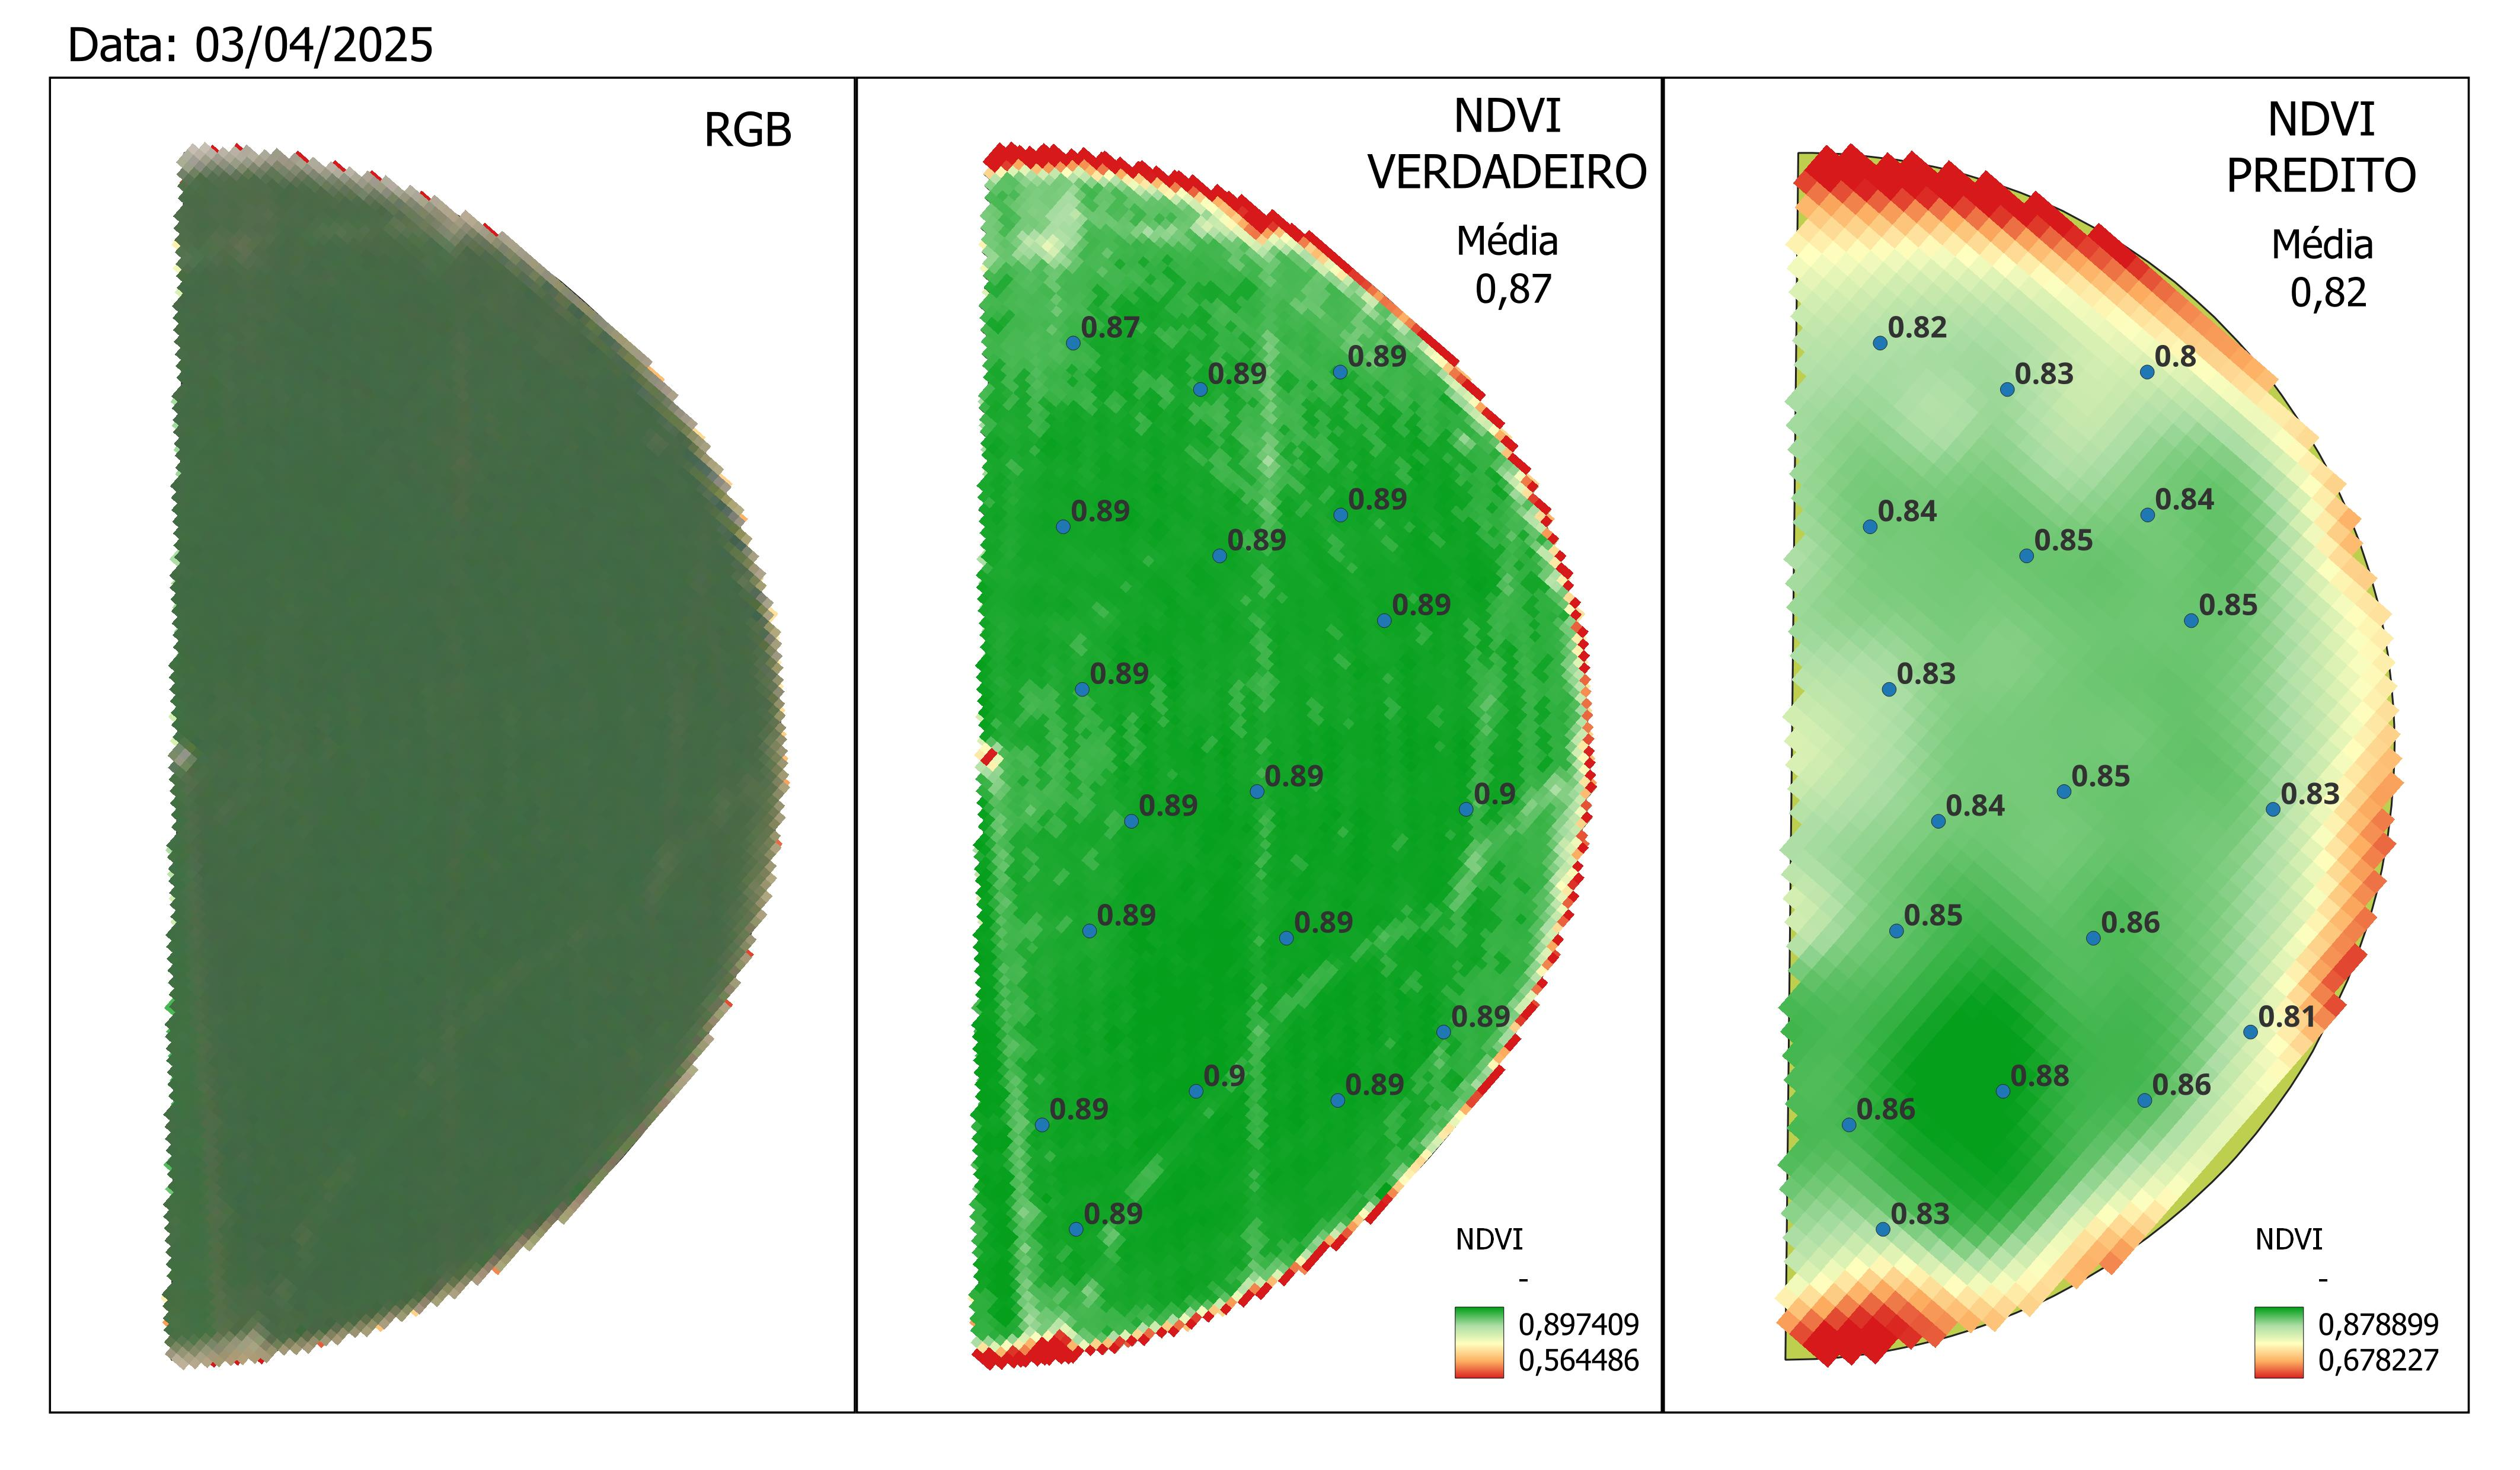

Ao comparar as imagens preditas de NDVI com as imagens reais do Sentinel-2, observamos algumas características importantes:

**1. Diferença nos Valores Absolutos:**

Os valores preditos de NDVI tendem a ser consistentemente menores do que os valores reais. Isso ocorre porque utilizamos a média móvel das últimas 3 imagens como uma das principais variáveis preditoras. Essa abordagem suaviza as variações temporais, resultando em valores mais baixos.

**2. Manutenção da Variabilidade Espacial:**

Apesar das diferenças nos valores absolutos, o objetivo principal do estudo foi alcançado: preservar a variabilidade espacial. As imagens preditas conseguem identificar com precisão as áreas de baixo e alto vigor vegetativo.

**3. Correlação Temporal:**

Nas imagens de janeiro e fevereiro, durante o início do ciclo da cultura, observamos uma correlação mais forte entre os valores preditos e os valores reais. Isso pode ser atribuído ao fato de que, nesse período, o dossel ainda está se desenvolvendo, e as variações espaciais são mais evidentes.

Já nas imagens de março e abril, com o fechamento do dossel, a correlação diminui ligeiramente. Isso ocorre porque, nesse estágio, o NDVI atinge valores mais altos e homogêneos, reduzindo a variabilidade espacial que o modelo pode capturar.

No entanto, ao analisar a curva fenológica ao longo do tempo, observamos que ela se comporta conforme o esperado, com os valores de NDVI subindo durante os picos vegetativos. Esse comportamento reforça a capacidade do modelo de capturar padrões temporais e espaciais, mesmo que os valores absolutos apresentem pequenas diferenças em relação aos dados reais.

# Conclusão:

Apesar dos valores preditos de NDVI serem consistentemente mais baixos em relação aos valores reais, o modelo demonstrou ser eficaz na identificação de padrões espaciais e temporais. Essa capacidade é especialmente valiosa para detectar áreas com problemas de desenvolvimento ou estresse, mesmo que os valores absolutos não estejam perfeitamente alinhados com os dados observados.

No entanto, a utilização exclusiva de dados do Sentinel-2 pode limitar a precisão das predições, devido à frequência de revisita e à disponibilidade de dados. Para aprimorar o desempenho do modelo, seria interessante incorporar dados de outros satélites com maior frequência de revisita, ampliando a base de dados para o treinamento e predição. Essa abordagem pode melhorar a robustez do modelo e sua capacidade de capturar variações temporais e espaciais de forma mais detalhada.
